# TP1 : Analyse Exploratoire de Données (EDA) sous Python

### Identification de l'étudiant

In [1]:
# Nom : 
# Prénom : 
# Numéro d'étudiant : 

### Modalités de rendu

1. Chaque étudiant doit rendre un travail individuel.
2. Renommez ce fichier selon la convention : `TP1_Nom_Prenom.ipynb`.
3. Le rendu s'effectuera via le lien de dépôt communiqué par votre enseignant.
4. Assurez-vous que votre code s'exécute sans erreur (Menu : Kernel > Restart & Run All).

### Objectifs de la séance

L'application d'algorithmes d'apprentissage statistique nécessite le chargement, le nettoyage et l'analyse préalable des bases de données. Ce TP introduit les outils standards de l'écosystème Python :
- `pandas` : manipulation des structures de données.
- `matplotlib` et `seaborn` : visualisation statistique.

La séance comporte deux parties parallèles :
1. **Partie 1 (Guidée)** : Étude du jeu de données *Palmer Penguins*.
2. **Partie 2 (Application)** : Étude du jeu de données *Titanic*.

### Documentation utile
- [Pandas User Guide](https://pandas.pydata.org/docs/user_guide/index.html)
- [Seaborn Examples](https://seaborn.pydata.org/examples/index.html)
- [Scikit-Learn OpenML](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html)

---

## Partie 1 : Étude du jeu de données Palmer Penguins

Le jeu de données Palmer Penguins contient des relevés biométriques concernant trois espèces de manchots observées en Antarctique.

![Espèces de manchots](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)

### 1.1 Importation des modules

Exécutez la cellule suivante pour charger les librairies nécessaires. Nous utiliserons `fetch_openml` pour récupérer les données.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Configuration pour définir le style graphique
sns.set_theme(style="whitegrid", palette="muted")

### 1.2 Chargement des données

La fonction `fetch_openml` permet de télécharger des bases de données standards.
Nous cherchons le dataset avec l'ID **42585**.

In [3]:
# Complétez les points de suspension
# L'argument parser='auto' est recommandé pour les versions récentes de sklearn
penguins_raw = fetch_openml(data_id=42585, as_frame=True, parser='auto')

# On extrait le DataFrame pandas de l'objet résultat
df_penguins = penguins_raw.frame

### 1.3 Inspection des données

Il est nécessaire de vérifier que les données ont été correctement chargées en affichant les premières lignes et les dimensions du tableau.

In [5]:
# Affichez les 5 premières lignes avec la méthode head()
display(df_penguins.head())

# Affichez les dimensions (nombre de lignes, nombre de colonnes) via l'attribut shape
print("Dimensions :", df_penguins.shape)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


Dimensions : (344, 7)


Utilisez la méthode `info()` pour inspecter le type des variables (float, int, category) et repérer le nombre de valeurs non-nulles.

In [6]:
# Affichez les informations techniques du DataFrame
df_penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            344 non-null    category
 1   island             344 non-null    category
 2   culmen_length_mm   342 non-null    float64 
 3   culmen_depth_mm    342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                334 non-null    category
dtypes: category(3), float64(4)
memory usage: 12.3 KB


Utilisez la méthode `describe()` pour obtenir les statistiques descriptives (moyenne, écart-type, quartiles) des variables numériques.

In [7]:
# Affichez les statistiques descriptives
display(df_penguins.describe())

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### 1.4 Manipulation et filtrage

Nous souhaitons isoler un sous-groupe spécifique : les manchots de l'île **'Torgersen'** dont la masse corporelle (**body_mass_g**) est strictement supérieure à **4000** grammes.

In [ ]:
# Complétez les conditions de filtrage
# Rappel : pour le ET logique, utilisez l'opérateur &
gros_manchots = df_penguins[(df_penguins['island'] == 'Torgersen') & (df_penguins['body_mass_g'] > 4000)]

display(gros_manchots.head())

### 1.5 Traitement des valeurs manquantes

Les modèles mathématiques ne gèrent pas les données manquantes (NaN). Commençons par les compter.

In [8]:
# Utilisez isna() suivi de sum() pour compter les NaN par colonne
print(df_penguins.isna().sum())

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


Nous allons imputer (remplacer) les valeurs manquantes de la masse par la médiane, qui est moins sensible aux valeurs extrêmes que la moyenne.

In [9]:
# Calculez la médiane de la colonne 'body_mass_g'
mediane_masse = df_penguins['body_mass_g'].median()
print(f"La médiane de la masse est : {mediane_masse}")

# Remplacez les NaN de cette colonne par la médiane avec fillna()
df_penguins['body_mass_g'] = df_penguins['body_mass_g'].fillna(mediane_masse)

La médiane de la masse est : 4050.0


Pour les autres colonnes contenant encore des valeurs manquantes (comme le sexe), nous supprimons simplement les lignes concernées.

In [10]:
# Supprimez les lignes avec des valeurs manquantes restantes
df_clean = df_penguins.dropna()

print("Dimensions avant nettoyage :", df_penguins.shape)
print("Dimensions après nettoyage :", df_clean.shape)

Dimensions avant nettoyage : (344, 7)
Dimensions après nettoyage : (334, 7)


### 1.6 Ingénierie des caractéristiques (Feature Engineering)

Il est souvent utile de créer de nouvelles variables à partir des existantes pour aider les algorithmes d'apprentissage. Nous allons catégoriser les manchots selon leur masse (Léger, Moyen, Lourd) en utilisant la méthode `apply`.

In [11]:
# Fonction de catégorisation
def categoriser_poids(masse):
    if masse < 3500:
        return 'Léger'
    elif masse <= 4500:
        return 'Moyen'
    else:
        return 'Lourd'

# Application de la fonction sur la colonne 'body_mass_g' via une fonction lambda ou directement
df_clean['weight_category'] = df_clean['body_mass_g'].apply(lambda x: categoriser_poids(x))

display(df_clean[['species', 'body_mass_g', 'weight_category']].head())

C:\Users\marco\AppData\Local\Temp\ipykernel_7584\1423699044.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['weight_category'] = df_clean['body_mass_g'].apply(lambda x: categoriser_poids(x))


,species,body_mass_g,weight_category
0,Adelie,3750.0,Moyen
1,Adelie,3800.0,Moyen
2,Adelie,3250.0,Léger
4,Adelie,3450.0,Léger
5,Adelie,3650.0,Moyen


### 1.7 Détection des valeurs aberrantes (Outliers)

Les valeurs extrêmes peuvent fausser l'apprentissage statistique. Une méthode robuste pour les détecter est l'écart interquartile (IQR).
Nous considérons comme outlier toute valeur située en dehors de l'intervalle : [Q1 - 1.5*IQR, Q3 + 1.5*IQR].

In [13]:
# Calcul des quartiles sur la longueur du culmen
Q1 = df_clean['culmen_length_mm'].quantile(0.25)
Q3 = df_clean['culmen_length_mm'].quantile(0.75)
IQR = Q3 - Q1

# Définition des bornes
borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

# Filtrage pour afficher uniquement les outliers
outliers = df_clean[(df_clean['culmen_length_mm'] < borne_inf) | (df_clean['culmen_length_mm'] > borne_sup)]

print(f"Nombre d'outliers détectés : {len(outliers)}")
display(outliers)

Nombre d'outliers détectés : 0


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,weight_category


### 1.8 Standardisation des données

Certains algorithmes (comme les k-plus proches voisins) sont sensibles à l'échelle des données. Il est courant de standardiser les variables numériques (moyenne = 0, écart-type = 1).
Formule du Z-score : z = (x - moy) / std

In [14]:
# Calcul de la moyenne et de l'écart-type de la masse
mean_mass = df_clean['body_mass_g'].mean()
std_mass = df_clean['body_mass_g'].std()

# Création d'une nouvelle colonne standardisée
df_clean['body_mass_g_scaled'] = (df_clean['body_mass_g'] - mean_mass) / std_mass

# Vérification : la nouvelle moyenne doit être proche de 0
print("Moyenne après standardisation :", df_clean['body_mass_g_scaled'].mean())

Moyenne après standardisation : -1.2764240762157488e-16


C:\Users\marco\AppData\Local\Temp\ipykernel_7584\2093502775.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['body_mass_g_scaled'] = (df_clean['body_mass_g'] - mean_mass) / std_mass


### 1.9 Visualisation statistique avancée

Exploitons la puissance de `seaborn` pour générer des graphiques complexes en une ligne.

Le **Jointplot** permet de visualiser simultanément la relation entre deux variables (nuage de points) et leur distribution individuelle (histogrammes sur les côtés).

Observons la corrélation entre deux dimensions physiques : longueur et profondeur du bec (culmen).

![Culmen](https://allisonhorst.github.io/palmerpenguins/reference/figures/culmen_depth.png)

<Figure size 800x800 with 0 Axes>

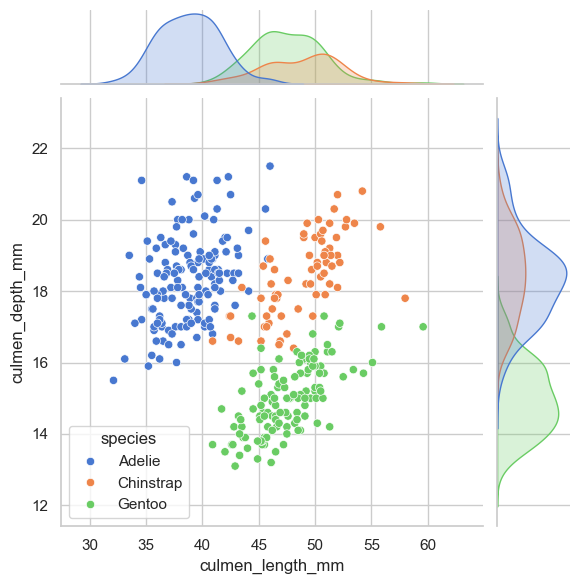

In [15]:
plt.figure(figsize=(8, 8))

# Utilisez sns.jointplot avec x='culmen_length_mm', y='culmen_depth_mm', hue='species'
sns.jointplot(data=df_clean, x='culmen_length_mm', y='culmen_depth_mm', hue='species', kind='scatter')

plt.show()

Le **Violinplot** (avec l'option `split=True`) est idéal pour comparer des distributions. Ici, nous comparons la masse corporelle des Mâles vs Femelles pour chaque espèce.

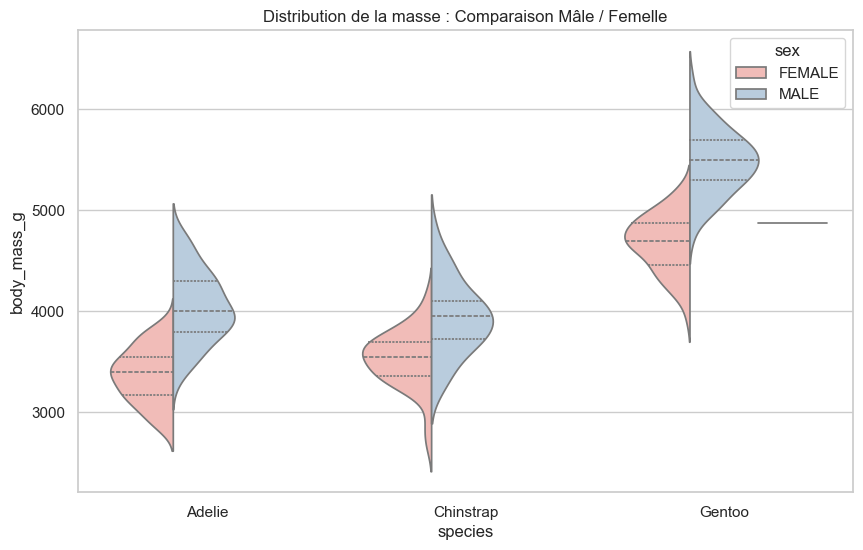

In [16]:
plt.figure(figsize=(10, 6))

# Utilisez sns.violinplot avec x='species', y='body_mass_g', hue='sex'
# Ajoutez l'argument split=True pour diviser le violon en deux
sns.violinplot(data=df_clean, x='species', y='body_mass_g', hue='sex', split=True, inner="quartile", palette="Pastel1")

plt.title("Distribution de la masse : Comparaison Mâle / Femelle")
plt.show()

Enfin, le **Pairplot** offre une vue d'ensemble de toutes les corrélations numériques du jeu de données.

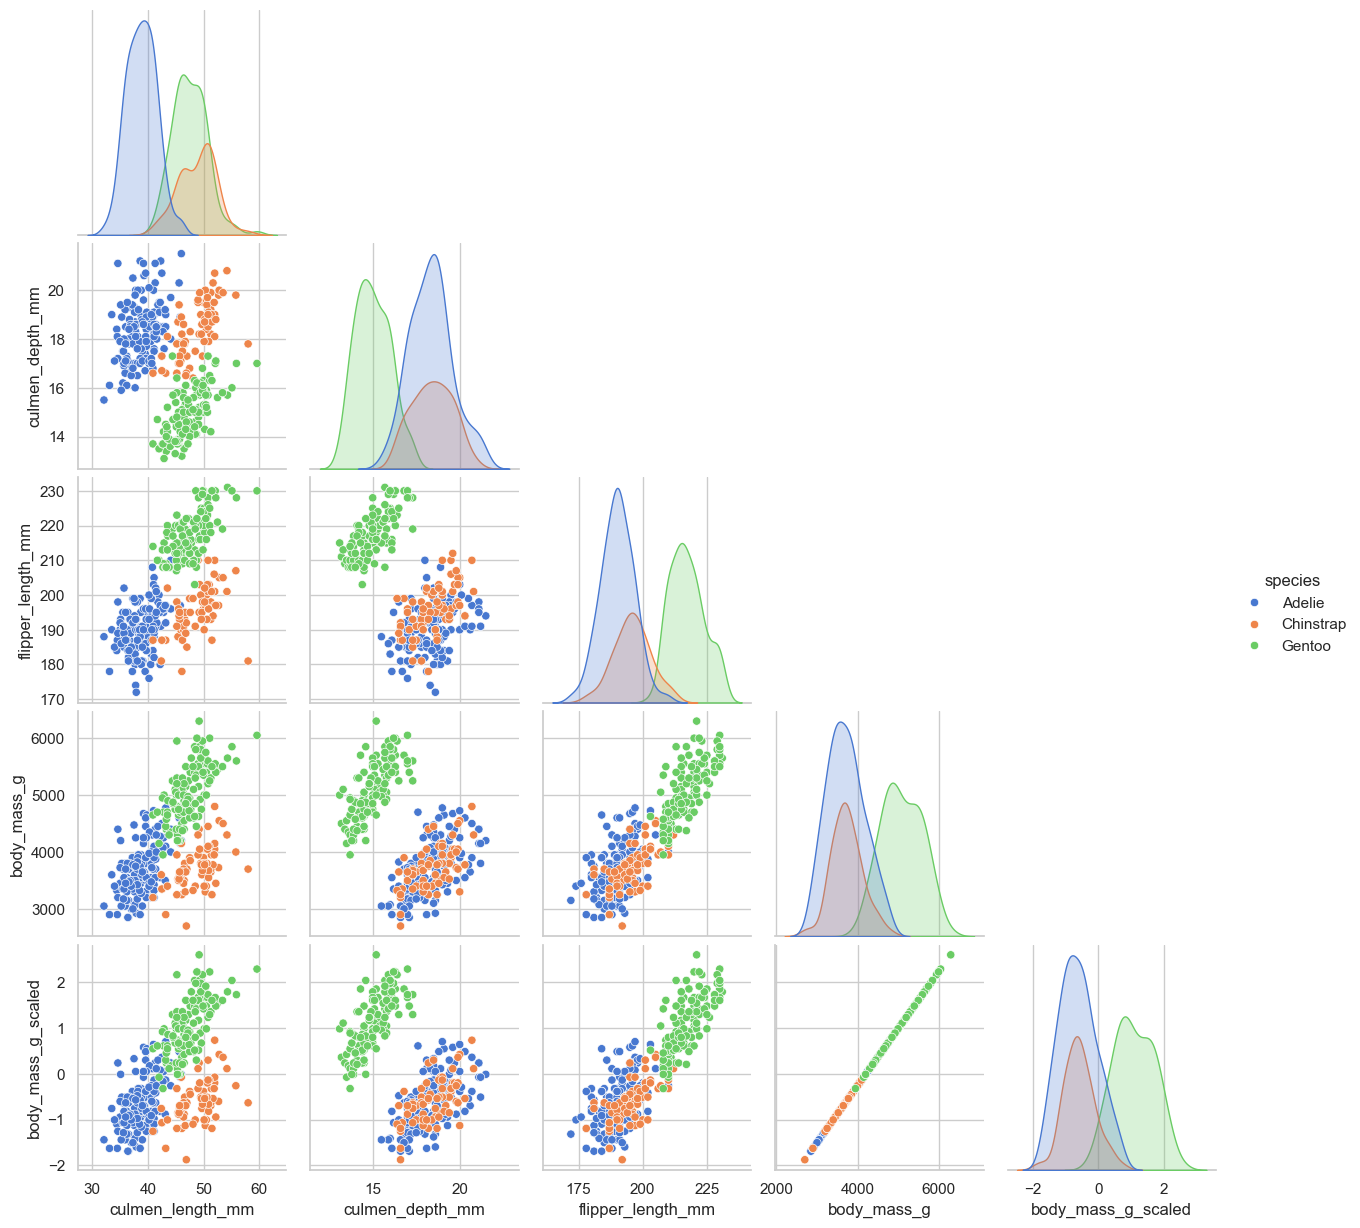

In [ ]:
# Attention : cela peut prendre quelques secondes à générer
# Mettre "species" ou "sex"
sns.pairplot(df_clean, hue='species', corner=True)
plt.show()

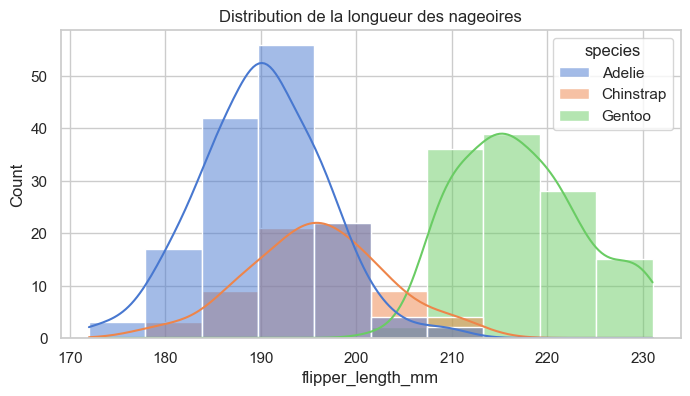

In [20]:
plt.figure(figsize=(8, 4))

# Utilisez sns.histplot. Paramètres clés : data, x, hue, kde=True
sns.histplot(data=df_clean, x='flipper_length_mm', hue='species', kde=True)

plt.title("Distribution de la longueur des nageoires")
plt.show()

Utilisons un Boxplot (boîte à moustaches) pour observer la masse corporelle selon l'île d'habitation.

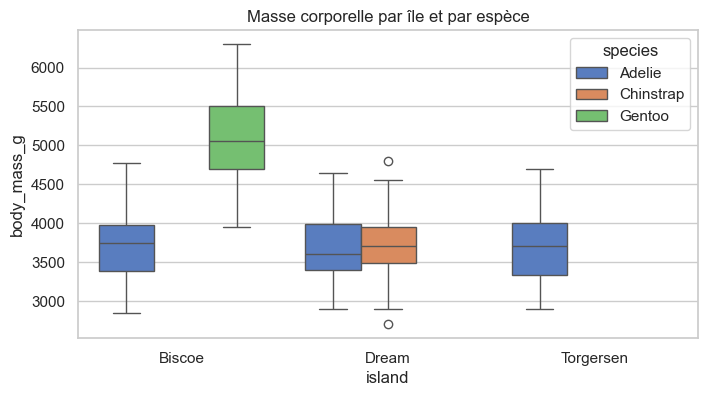

In [21]:
plt.figure(figsize=(8, 4))

# Utilisez sns.boxplot avec x='island', y='body_mass_g', et hue='species'
sns.boxplot(data=df_clean, x='island', y='body_mass_g', hue='species')

plt.title("Masse corporelle par île et par espèce")
plt.show()

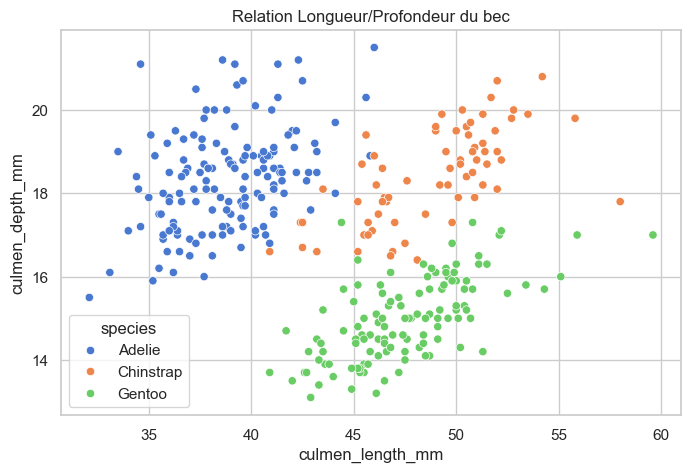

In [22]:
plt.figure(figsize=(8, 5))

# Utilisez sns.scatterplot avec x='culmen_length_mm', y='culmen_depth_mm', hue='species'
sns.scatterplot(data=df_clean, x='culmen_length_mm', y='culmen_depth_mm', hue='species')

plt.title("Relation Longueur/Profondeur du bec")
plt.show()

Enfin, affichons la matrice de corrélation pour identifier les variables liées linéairement.

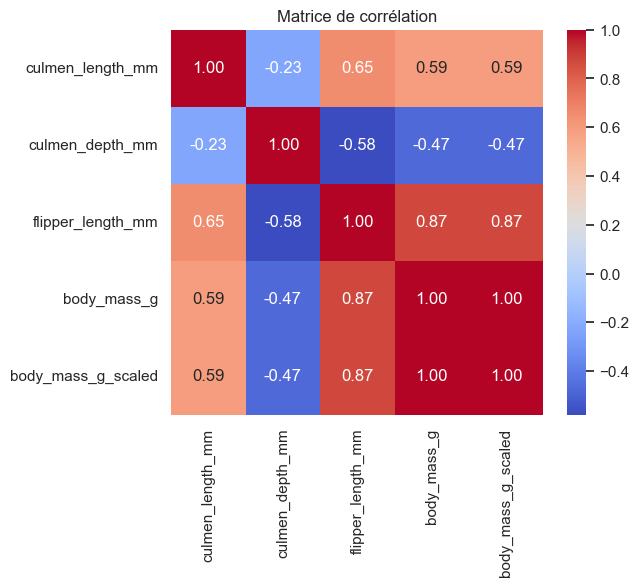

In [23]:
# On sélectionne uniquement les colonnes numériques pour le calcul de la corrélation
num_cols = df_clean.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(6, 5))

# Utilisez la méthode .corr() sur le DataFrame filtré, puis sns.heatmap
sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Matrice de corrélation")
plt.show()

### 1.10 Transformation des variables catégorielles

Les algorithmes de Machine Learning nécessitent des entrées numériques. Nous devons encoder les variables textuelles.

1. **Encodage binaire** pour le sexe (`map`).
2. **One-Hot Encoding** pour l'île (`get_dummies`).

In [24]:
# Transformation manuelle avec map : FEMALE devient 0, MALE devient 1
df_clean['sex_encoded'] = df_clean['sex'].map({'FEMALE': 0, 'MALE': 1})

# Création de variables indicatrices pour 'island' (drop_first=True évite la redondance)
df_ml_ready = pd.get_dummies(df_clean, columns=['island'], drop_first=True)

display(df_ml_ready.head())

C:\Users\marco\AppData\Local\Temp\ipykernel_7584\1482185551.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['sex_encoded'] = df_clean['sex'].map({'FEMALE': 0, 'MALE': 1})


,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,weight_category,body_mass_g_scaled,sex_encoded,island_Dream,island_Torgersen
0,Adelie,39.1,18.7,181.0,3750.0,MALE,Moyen,-0.570373,1.0,0,1
1,Adelie,39.5,17.4,186.0,3800.0,FEMALE,Moyen,-0.508249,0.0,0,1
2,Adelie,40.3,18.0,195.0,3250.0,FEMALE,Léger,-1.191618,0.0,0,1
4,Adelie,36.7,19.3,193.0,3450.0,FEMALE,Léger,-0.943120,0.0,0,1
5,Adelie,39.3,20.6,190.0,3650.0,MALE,Moyen,-0.694622,1.0,0,1


---

## Partie 2 : Étude du jeu de données Titanic

Appliquez les méthodes étudiées dans la première partie sur le jeu de données historique du Titanic. L'objectif est de préparer la variable cible `survived`.

### 2.1 Chargement et inspection

Chargez les données (identifiant OpenML : **40945**) et inspectez la structure du tableau.

In [26]:
# Chargez le dataset Titanic
titanic_raw = fetch_openml(data_id=40945, as_frame=True, parser='auto')
df_titanic = titanic_raw.frame

# Affichez les premières lignes
display(df_titanic.head())

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


Affichez les informations sur les types de colonnes. Notez que `survived` est probablement de type objet/catégorie et non numérique.

In [27]:
# Affichez les infos (types, NaN)
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 116.8+ KB


### 2.2 Nettoyage des données

La variable `survived` doit être numérique pour nos calculs (0 = décédé, 1 = survécu). Certaines colonnes comme le nom ou le numéro de ticket ne sont pas pertinentes pour une analyse statistique globale.

In [28]:
# Conversion de 'survived' en numérique
df_titanic['survived'] = pd.to_numeric(df_titanic['survived'])

# Liste des colonnes à supprimer
colonnes_a_supprimer = ['name', 'ticket', 'cabin', 'boat', 'body', 'home.dest']

# Suppression des colonnes (utilisez drop avec l'argument columns)
df_titanic = df_titanic.drop(columns=colonnes_a_supprimer)

# Vérification des dimensions après suppression
print("Dimensions :", df_titanic.shape)

Dimensions : (1309, 8)


Traitez maintenant les valeurs manquantes de la variable `age`. Remplacez les `NaN` par la médiane des âges.

In [29]:
# Calcul de la médiane de l'âge
mediane_age = df_titanic['age'].median()

# Remplacement des NaN par la médiane
df_titanic['age'] = df_titanic['age'].fillna(mediane_age)

# Suppression des dernières lignes incomplètes (s'il reste des NaN dans d'autres colonnes)
df_titanic_clean = df_titanic.dropna()

print("Dimensions finales :", df_titanic_clean.shape)

Dimensions finales : (1306, 8)


### 2.3 Manipulation et encodage

Transformez la variable `sex` en binaire (0 pour male, 1 pour female) et appliquez un encodage One-Hot sur la variable `embarked` (port d'embarquement).

In [30]:
# Encodage du sexe avec map
# Important : On force le type 'int' pour que le sexe apparaisse dans la matrice de corrélation
df_titanic_clean['sex'] = df_titanic_clean['sex'].map({'male': 0, 'female': 1}).astype(int)

# Encodage de 'embarked' avec get_dummies
df_titanic_ml = pd.get_dummies(df_titanic_clean, columns=['embarked'], drop_first=True)

display(df_titanic_ml.head())

C:\Users\marco\AppData\Local\Temp\ipykernel_7584\262687822.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_titanic_clean['sex'] = df_titanic_clean['sex'].map({'male': 0, 'female': 1}).astype(int)


,pclass,survived,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,1,1,1,29.0000,0,0,211.3375,0,1
1,1,1,0,0.9167,1,2,151.5500,0,1
2,1,0,1,2.0000,1,2,151.5500,0,1
3,1,0,0,30.0000,1,2,151.5500,0,1
4,1,0,1,25.0000,1,2,151.5500,0,1


### 2.4 Visualisation

Commencez par un diagramme en barres comptant le nombre de survivants.

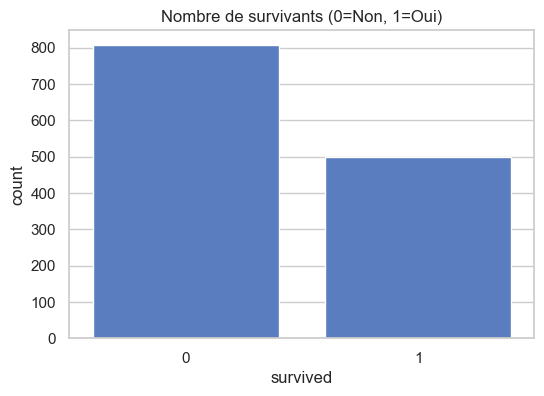

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_titanic_clean, x="survived")
plt.title("Nombre de survivants (0=Non, 1=Oui)")
plt.show()

Tracez l'histogramme des âges. 

**Note importante :** Vous observerez un pic artificiel important au centre. C'est normal : il correspond à la valeur médiane que nous avons utilisée pour remplacer toutes les données manquantes.

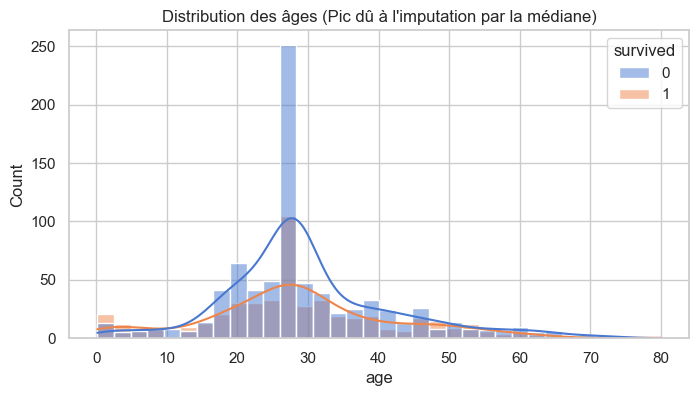

In [32]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df_titanic_clean, x='age', hue='survived', kde=True)
plt.title("Distribution des âges (Pic dû à l'imputation par la médiane)")
plt.show()

Utilisez un tableau croisé pour analyser le taux de survie selon le sexe et la classe.

In [33]:
tableau_survie = pd.pivot_table(df_titanic_clean, values='survived', index='pclass', columns='sex', aggfunc='mean')
display(tableau_survie)

sex,0,1
pclass,,
1,0.340782,0.964789
2,0.146199,0.886792
3,0.152439,0.490741


**Analyse :** Double-cliquez ici pour écrire votre conclusion sur l'impact du sexe et de la classe sociale.

### 2.5 Matrice de corrélation

Pour interpréter correctement la matrice, voici la signification des variables moins évidentes :
*   `sibsp` : Nombre de frères, sœurs, époux ou épouses à bord.
*   `parch` : Nombre de parents ou enfants à bord.
*   `pclass` : Classe du billet (1 = 1ère classe, 3 = 3ème classe).

Assurez-vous que la variable `sex` a bien été transformée en nombres (0/1) pour apparaître dans le graphique.

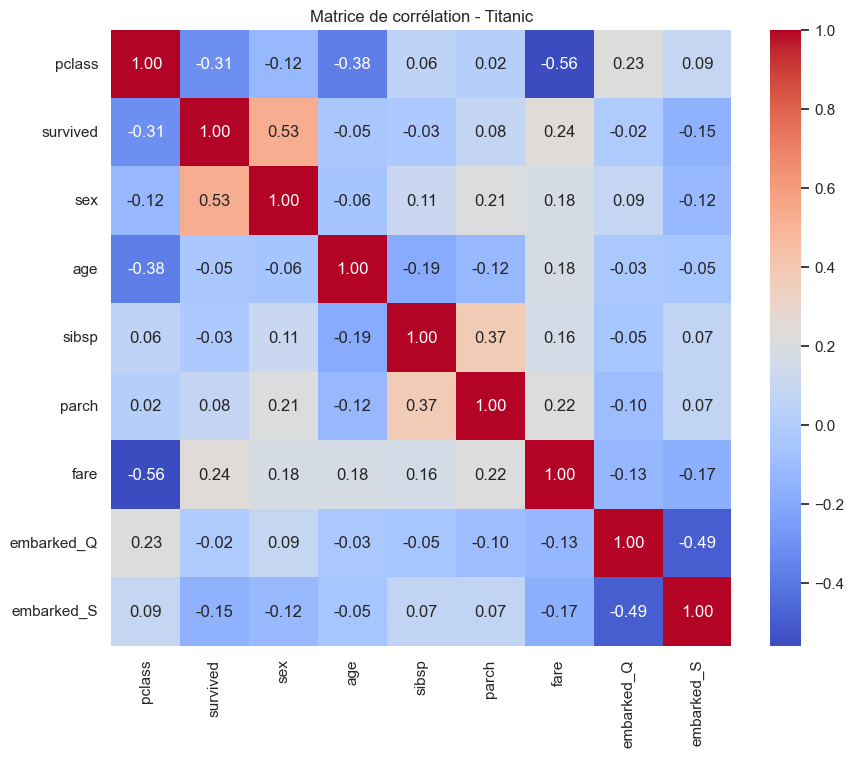

In [34]:
# Sélection des variables numériques (incluant le sexe encodé)
vars_numeriques = df_titanic_ml.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 8))
sns.heatmap(df_titanic_ml[vars_numeriques].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation - Titanic")
plt.show()

**Analyse :** Double-cliquez ici pour identifier les variables les plus corrélées à 'survived'.

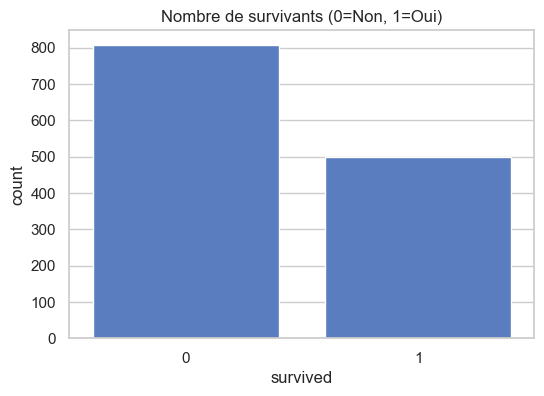

In [35]:
plt.figure(figsize=(6, 4))

# Utilisez sns.countplot sur la variable 'survived'
sns.countplot(data=df_titanic_clean, x="survived")

plt.title("Nombre de survivants (0=Non, 1=Oui)")
plt.show()

Regardons si l'âge a influencé la survie en superposant les histogrammes.

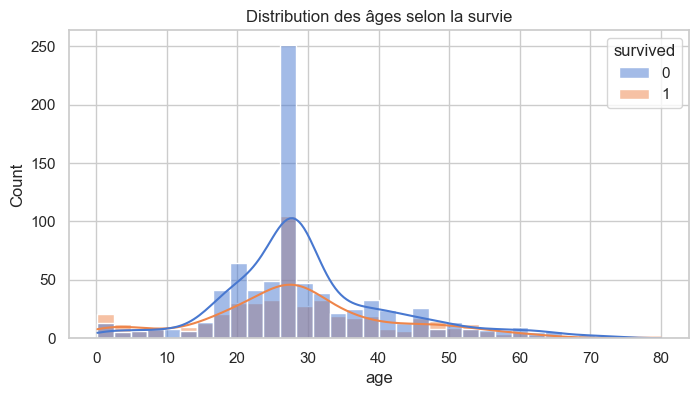

In [36]:
plt.figure(figsize=(8, 4))

# Utilisez histplot avec x='age' et hue='survived'
sns.histplot(data=df_titanic_clean, x='age', hue='survived', kde=True)

plt.title("Distribution des âges selon la survie")
plt.show()